In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report
import joblib

In [6]:
df = pd.read_csv("C:/Users/Saini/Desktop/cancer-care/cancer_detect.csv")
df = df.drop(columns=["CancerTypeInput"], errors='ignore')  # optional internal column


In [7]:
df.head()

,Age,Gender,Symptoms,FamilyHistory,SmokingUse,PhysicalActivity,DietQuality,SupportNeeded,CancerType,TreatmentStatus,CancerStage,SupportType,SupportTips,Remedies,DietPlan
0,56,Female,"Fatigue, Weight Loss",No,Yes,Low,Average,Financial,Lung Cancer,Not Started,Stage IV,Financial,Talk to a counselor and educate family members...,Yoga and breathing exercises,"Low-sugar, high-fiber foods"
1,39,Other,"Lump, Fatigue",No,Yes,Moderate,Poor,Emotional,Breast Cancer,Completed,Stage I,Emotional,Talk to a counselor and educate family members...,Yoga and breathing exercises,Anti-inflammatory diet with turmeric and ginger
2,46,Other,Skin Changes,Yes,No,Moderate,Average,Emotional,Skin Cancer,Completed,Stage II,Emotional,Talk to a counselor and educate family members...,Nutritional supplements,"Low-sugar, high-fiber foods"
3,37,Female,"Fatigue, Weight Loss",Yes,Yes,High,Poor,"Medical, Financial",Colon Cancer,Not Started,Stage II,"Medical, Financial",Join a local support group and maintain follow...,"Herbal tea, meditation",Balanced meals with lean meats and leafy greens
4,20,Other,Abdominal Pain,No,Yes,Moderate,Good,Medical,Leukemia Cancer,Not Started,Stage II,Medical,Wear sunscreen and monitor moles regularly.,"Herbal tea, meditation",Calorie-dense nutritious smoothies and fruits


In [8]:
input_cols = [
    'Age', 'Gender', 'Symptoms', 'FamilyHistory', 'SmokingUse',
    'PhysicalActivity', 'DietQuality', 'SupportNeeded'
]

output_cols = [
    'CancerType', 'TreatmentStatus', 'CancerStage',
    'SupportType', 'SupportTips', 'Remedies', 'DietPlan'
]

X = df[input_cols]
y = df[output_cols]


In [9]:
label_encoders = {}
for col in output_cols:
    le = LabelEncoder()
    y[col] = le.fit_transform(y[col])
    label_encoders[col] = le


C:\Users\Saini\AppData\Local\Temp\ipykernel_13708\156305833.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y[col] = le.fit_transform(y[col])
C:\Users\Saini\AppData\Local\Temp\ipykernel_13708\156305833.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y[col] = le.fit_transform(y[col])
C:\Users\Saini\AppData\Local\Temp\ipykernel_13708\156305833.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See t

In [11]:
categorical_features = [
    'Gender', 'Symptoms', 'FamilyHistory', 'SmokingUse',
    'PhysicalActivity', 'DietQuality', 'SupportNeeded'
]

preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)],
    remainder='passthrough'  # Keeps 'Age' column as numeric
)

In [12]:
pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', MultiOutputClassifier(RandomForestClassifier(random_state=42)))
])


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline.fit(X_train, y_train)


C:\Users\Saini\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'Symptoms',
                                                   'FamilyHistory',
                                                   'SmokingUse',
                                                   'PhysicalActivity',
                                                   'DietQuality',
                                                   'SupportNeeded'])])),
                ('classifier',
                 MultiOutputClassifier(estimator=RandomForestClassifier(random_state=42)))])

In [14]:
y_pred = pipeline.predict(X_test)

for i, col in enumerate(output_cols):
    print(f"\n--- {col} ---")
    print(classification_report(y_test[col], y_pred[:, i]))



--- CancerType ---
              precision    recall  f1-score   support

           0       0.11      0.20      0.14         5
           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         3
           3       1.00      0.20      0.33         5
           4       0.00      0.00      0.00         4

    accuracy                           0.10        20
   macro avg       0.22      0.08      0.10        20
weighted avg       0.28      0.10      0.12        20


--- TreatmentStatus ---
              precision    recall  f1-score   support

           0       0.50      0.25      0.33         4
           1       0.00      0.00      0.00         8
           2       0.17      0.33      0.22         3
           3       0.27      0.60      0.38         5

    accuracy                           0.25        20
   macro avg       0.23      0.30      0.23        20
weighted avg       0.19      0.25      0.19        20


--- CancerStage ---
          

C:\Users\Saini\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Saini\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Saini\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

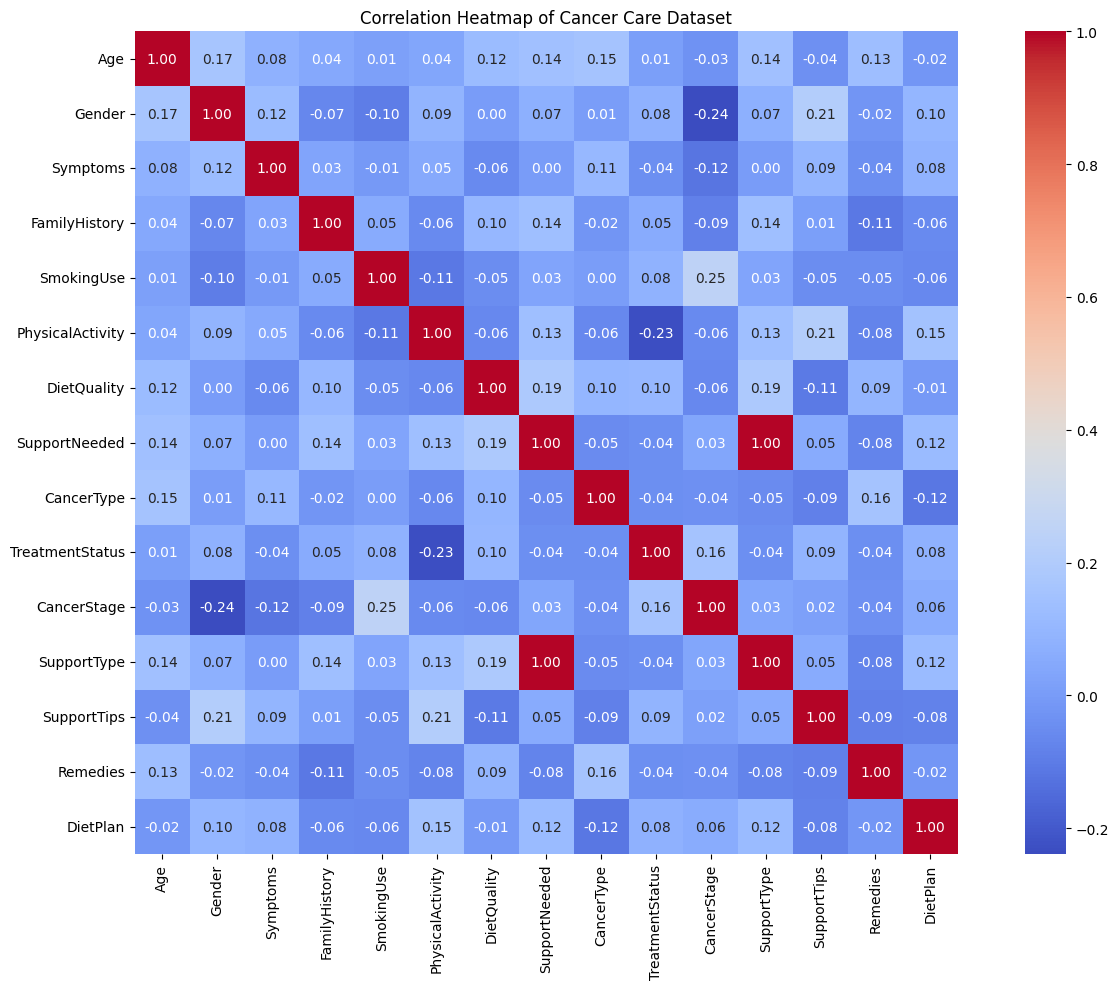

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convert categorical variables to numerical temporarily for correlation matrix
df_numeric = df.copy()

# Encode categorical columns for correlation heatmap
for col in df_numeric.columns:
    if df_numeric[col].dtype == 'object':
        df_numeric[col] = df_numeric[col].astype('category').cat.codes

# Generate the correlation matrix
correlation_matrix = df_numeric.corr()

# Plot the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap of Cancer Care Dataset")
plt.tight_layout()
plt.show()


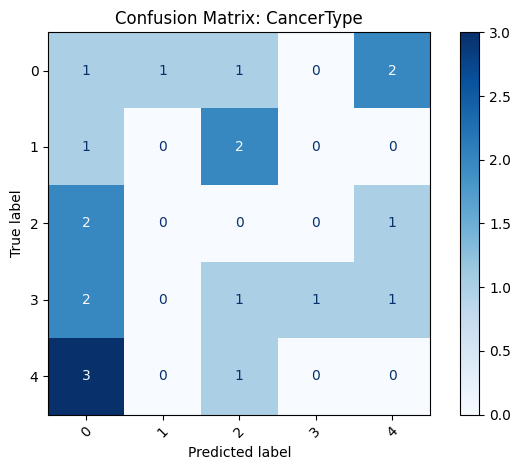

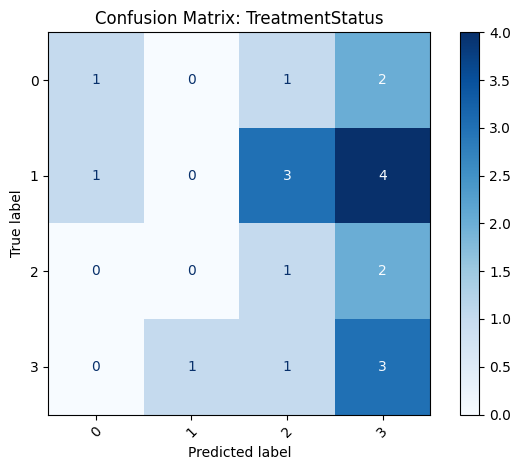

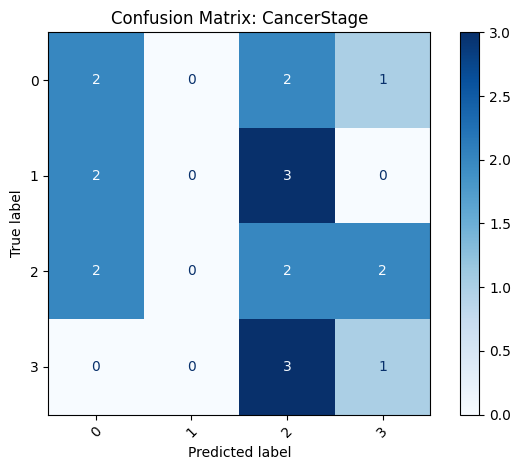

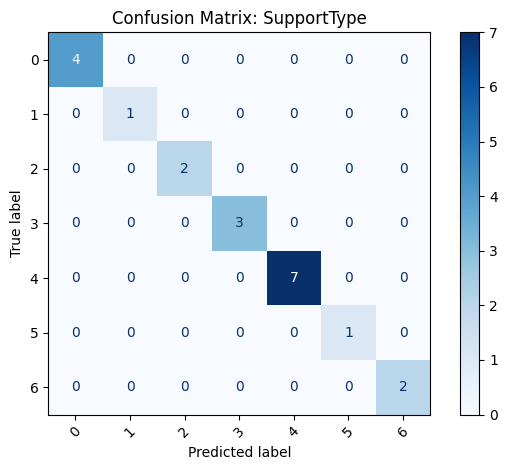

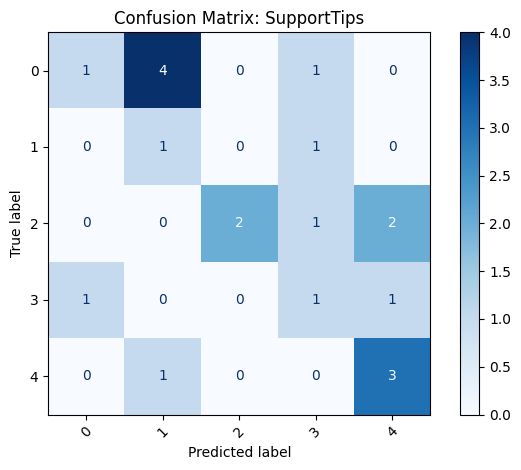

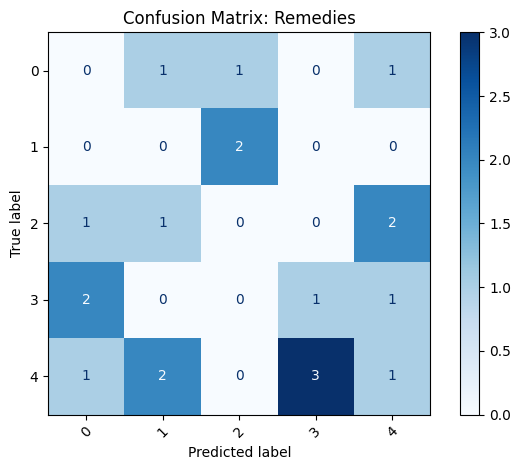

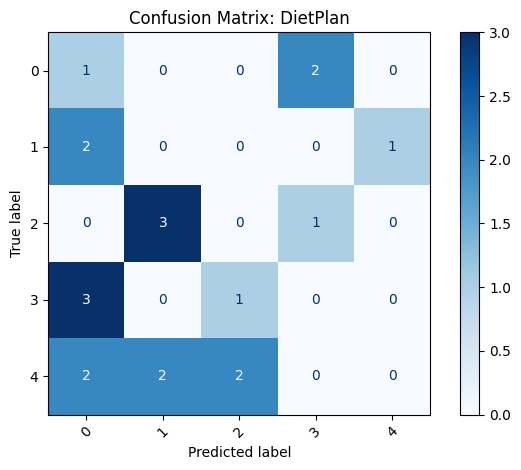

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict on test set
y_pred = pipeline.predict(X_test)

# Plot confusion matrix for each output column
for i, col in enumerate(output_cols):
    cm = confusion_matrix(y_test[col], y_pred[:, i])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix: {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
